In [2]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.utils as vutils

import matplotlib.pyplot as plt
import random
import numpy as np
from tqdm import tqdm
import timeit
import os

DATA_DIR="/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Train"
BATCH_SIZE = 128
IMG_SIZE = 64
CHANNELS = 3
INPUT_VECTOR_DIM = 100
FEATURE_MAP_DIM = 64
LR = 2e-4
BETA1 = 0.5
EPOCHS = 500
RANDOM_SEED = 42
CHECKPOINT = "checkpoints"

if not os.path.exists(CHECKPOINT):
    os.makedirs(CHECKPOINT)
    print(f"Created checkpoint directory: {CHECKPOINT}")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
class Discriminator(nn.Module):
  def __init__(self, feature_map_dim, channels):
    super(Discriminator, self).__init__()
    self.conv_1 = nn.Conv2d(in_channels=channels, out_channels=feature_map_dim*2, kernel_size=4, stride=2, padding=1, bias=False )
    self.conv_2 = nn.Conv2d(in_channels=feature_map_dim*2, out_channels=feature_map_dim*4, kernel_size=4, stride=2, padding=1, bias=False )
    self.conv_3 = nn.Conv2d(in_channels=feature_map_dim*4, out_channels=feature_map_dim*8, kernel_size=4, stride=2, padding=1, bias=False )
    self.conv_4 = nn.Conv2d(in_channels=feature_map_dim*8, out_channels=feature_map_dim*16, kernel_size=4, stride=2, padding=1, bias=False )
    self.conv_5 = nn.Conv2d(in_channels=feature_map_dim*16, out_channels=1, kernel_size=4, stride=1, padding=0, bias=False )

    self.leaky_relu = nn.LeakyReLU(0.2, inplace=True)

    self.batch_norm_1 = nn.BatchNorm2d(feature_map_dim*4)
    self.batch_norm_2 = nn.BatchNorm2d(feature_map_dim*8)
    self.batch_norm_3 = nn.BatchNorm2d(feature_map_dim*16)

    self.sigmoid = nn.Sigmoid()

  def forward(self, inp):
    x = self.conv_1(inp)
    x = self.leaky_relu(x)

    x = self.conv_2(x)
    x = self.batch_norm_1(x)
    x = self.leaky_relu(x)

    x = self.conv_3(x)
    x = self.batch_norm_2(x)
    x = self.leaky_relu(x)

    x = self.conv_4(x)
    x = self.batch_norm_3(x)
    x = self.leaky_relu(x)

    x = self.conv_5(x)
    out = self.sigmoid(x)

    return out

In [4]:
discriminator = Discriminator(FEATURE_MAP_DIM, CHANNELS).to(device)
x =  torch.randn(BATCH_SIZE, CHANNELS, IMG_SIZE, IMG_SIZE).to(device)
dis_out = discriminator(x)
print(dis_out.size())

torch.Size([128, 1, 1, 1])


In [5]:
class Generator(nn.Module):
  def __init__(self, input_vector, feature_map_dim, channels):
    super(Generator, self).__init__()
    self.convt_1 = nn.ConvTranspose2d(in_channels=input_vector, out_channels=feature_map_dim*16, kernel_size=4, stride=1, padding=0, bias=False)
    self.convt_2 = nn.ConvTranspose2d(in_channels=feature_map_dim*16, out_channels=feature_map_dim*8, kernel_size=4, stride=2, padding=1, bias=False)
    self.convt_3 = nn.ConvTranspose2d(in_channels=feature_map_dim*8, out_channels=feature_map_dim*4, kernel_size=4, stride=2, padding=1, bias=False)
    self.convt_4 = nn.ConvTranspose2d(in_channels=feature_map_dim*4, out_channels=feature_map_dim*2, kernel_size=4, stride=2, padding=1, bias=False)
    self.convt_5 = nn.ConvTranspose2d(in_channels=feature_map_dim*2, out_channels=channels, kernel_size=4, stride=2, padding=1, bias=False)

    self.relu = nn.ReLU(True)

    self.batch_norm_1 = nn.BatchNorm2d(feature_map_dim*16)
    self.batch_norm_2 = nn.BatchNorm2d(feature_map_dim*8)
    self.batch_norm_3 = nn.BatchNorm2d(feature_map_dim*4)
    self.batch_norm_4 = nn.BatchNorm2d(feature_map_dim*2)

    self.tanh = nn.Tanh()

  def forward(self, inp):
    x = self.convt_1(inp)
    x = self.batch_norm_1(x)
    x = self.relu(x)

    x = self.convt_2(x)
    x = self.batch_norm_2(x)
    x = self.relu(x)

    x = self.convt_3(x)
    x = self.batch_norm_3(x)
    x = self.relu(x)

    x = self.convt_4(x)
    x = self.batch_norm_4(x)
    x = self.relu(x)

    x = self.convt_5(x)
    out = self.tanh(x)

    return out

In [6]:
generator = Generator(INPUT_VECTOR_DIM, FEATURE_MAP_DIM, CHANNELS).to(device)
noise = torch.randn(BATCH_SIZE, INPUT_VECTOR_DIM, 1, 1, device=device)
gen_out = generator(noise)
print(gen_out.size())

torch.Size([128, 3, 64, 64])


In [7]:
dataset = ImageFolder(DATA_DIR,
                      transform=transforms.Compose([
                          transforms.Resize(IMG_SIZE),
                          transforms.CenterCrop(IMG_SIZE),
                          transforms.ToTensor(),
                          transforms.Normalize(*((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
                      ]))
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True)

Generator params: 12658432
Discriminator params: 11036160


 28%|██▊       | 49/177 [02:55<07:25,  3.48s/it]/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/.venv/lib/python3.10/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 177/177 [10:04<00:00,  3.41s/it]


Discriminator Loss EPOCH 1: 14295.3305
Generator Loss EPOCH 1: 7.3484


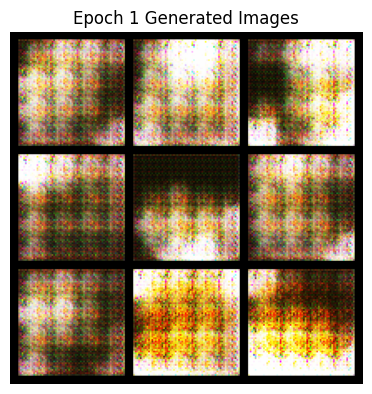

  0%|          | 2/500 [19:24<79:56:37, 577.91s/it]

Discriminator Loss EPOCH 2: 13179.9867
Generator Loss EPOCH 2: 3.5858


  1%|          | 3/500 [28:47<78:49:40, 570.99s/it]

Discriminator Loss EPOCH 3: 11266.9599
Generator Loss EPOCH 3: 3.8828


  1%|          | 4/500 [37:35<76:21:03, 554.16s/it]

Discriminator Loss EPOCH 4: 10835.5433
Generator Loss EPOCH 4: 3.9838


  1%|          | 5/500 [46:13<74:22:52, 540.96s/it]

Discriminator Loss EPOCH 5: 11641.5824
Generator Loss EPOCH 5: 3.9374


  1%|          | 5/500 [49:59<82:29:22, 599.92s/it]


KeyboardInterrupt: 

In [8]:
criterion = nn.BCELoss()

discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, 0.999))
generator_optimizer = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, 0.999))

generator.train()
discriminator.train()

generator_params = sum(p.numel() for p in generator.parameters())
discriminator_params = sum(p.numel() for p in discriminator.parameters())

print(f"Generator params: {generator_params}")
print(f"Discriminator params: {discriminator_params}")

def save_checkpoint(epoch, generator, discriminator, gen_opt, disc_opt, checkpoint_dir=CHECKPOINT):
    checkpoint = {
        "epoch": epoch,
        "generator_state_dict":  generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "generator_optimizer_state_dict": gen_opt.state_dict(),
        "discriminator_optimizer_state_dict": disc_opt.state_dict(),
    }
    torch.save(checkpoint, f"{CHECKPOINT}/checkpoint_epoch_{epoch}.pth")
    print(f"Checkpoint saved at epoch {epoch}")

def load_checkpoint(checkpoint_path, generator, discriminator, gen_opt, disc_opt):
    checkpoint = torch.load(checkpoint_path)
    generator.load_state_dict(checkpoint["generator_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
    gen_opt.load_state_dict(checkpoint["gen_opt_state_dict"])
    disc_opt.load_state_dict(checkpoint["disc_opt_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Checkpoint loaded. Resuming from epoch {start_epoch}")
    return start_epoch

start_epoch = 0

resume_training = False
checkpoint_path = f"{CHECKPOINT}/checkpoint_epoch_100.pth"

if resume_training:
    start_epoch = load_checkpoint(checkpoint_path, generator, discriminator, generator_optimizer, discriminator_optimizer)

start = timeit.default_timer()
for epoch in tqdm(range(start_epoch, EPOCHS), position=0, leave=True):
  generator_running_lost = 0
  discriminator_running_lost = 0
  for idx, data in enumerate(tqdm(dataloader, position=0, leave=True)):
    img_data = data[0].to(device)
    dummy_labels = data[1]

    real_labels = torch.full((dummy_labels.size()), 1., dtype=torch.float).to(device)
    fake_labels = torch.full((dummy_labels.size()), 0., dtype=torch.float).to(device)

    discriminator_real_out = discriminator(img_data).view(-1)
    discriminator_real_loss = criterion(discriminator_real_out, real_labels)
    discriminator.zero_grad()
    discriminator_real_loss.backward()

    noise = torch.randn(dummy_labels.size()[0], INPUT_VECTOR_DIM, 1, 1).to(device)
    generator_fake_out = generator(noise)
    discriminator_fake_out = discriminator(generator_fake_out.detach()).view(-1)
    discriminator_fake_loss = criterion(discriminator_fake_out, fake_labels)
    discriminator_fake_loss.backward()
    discriminator_running_lost += discriminator_real_loss.item() + discriminator_fake_loss.item()
    discriminator_optimizer.step()

    discriminator_fake_out = discriminator(generator_fake_out).view(-1)
    generator_loss = criterion(discriminator_fake_out, real_labels)
    generator_running_lost += generator_loss.item()
    generator.zero_grad()
    generator_loss.backward()
    generator_optimizer.step()

  discriminator_loss = discriminator_running_lost / 2 *(idx+1)
  generator_loss = generator_running_lost / (idx+1)

  print(f"Discriminator Loss EPOCH {epoch+1}: {discriminator_loss:.4f}")
  print(f"Generator Loss EPOCH {epoch+1}: {generator_loss:.4f}")

  if epoch % 20 == 0:  
    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title(f"Epoch {epoch+1} Generated Images")
    plt.imshow(np.transpose(vutils.make_grid(generator_fake_out[:9], padding=5, normalize=True, nrow=3).cpu(), (1,2,0)))
    plt.show()

  if (epoch + 1) % 100 == 0:
    save_checkpoint(epoch, generator, discriminator, generator_optimizer, discriminator_optimizer)

stop = timeit.default_timer()
print(f"Training time: {stop-start:.2f}s")

In [9]:
torch.cuda.empty_cache()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9966984..0.97630227].


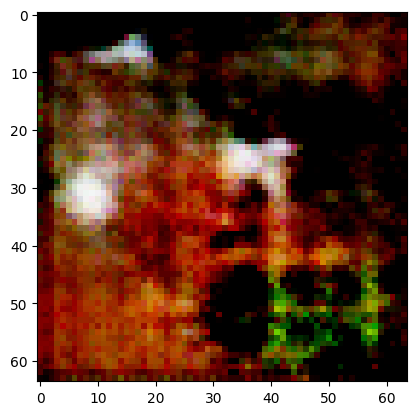

In [18]:
noise = torch.randn(dummy_labels.size()[0], INPUT_VECTOR_DIM, 1, 1).to(device)
generator_fake_out = generator(noise)
plt.imshow(generator_fake_out[2].detach().cpu().permute(1, 2, 0))

In [19]:
https://www.kaggle.com/code/ashishpatel26/gan-beginner-tutorial-for-pytorch-celeba-dataset?scriptVersionId=6886724&cellId=23

SyntaxError: invalid syntax (1127674942.py, line 1)

In [20]:
import imageio

images = []
for epoch in range(EPOCHS):
    for i in range(total_batch):
        if(i+1)%sample_step == 0:
            img_name = '../fake_samples-' + str(epoch + 1) + '-' + str(i + 1) + '.png'
            images.append(imageio.imread(img_name))
            print("epoch : {}, step : {}".format(epoch+1, i+1))
imageio.mimsave('dcgan_celebA_generation_animation.gif', images, fps=5)

NameError: name 'total_batch' is not defined